# Fase 1
## Exploración y limpieza de datos (EDA)


In [3]:
# importamos las librerias que necesitamos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

In [4]:
df_vuelos = pd.read_csv("./files/Customer Flight Activity.csv")
df_cliente = pd.read_csv("./files/Customer Loyalty History.csv")

#### -  Damos un primer vistazo a lo que hay dentro de los datos con el head

In [91]:
df_cliente.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [92]:
df_vuelos.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0


#### - Con el info, vemos mas en detalle, como vienen los datos, con que tipos, vemos los nulos, numero de columnas, etc..

In [93]:
df_vuelos.info()

# los datos de este DF nos indican que son numéricas y que a simple vista no presentan nulos

<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [94]:
df_cliente.info()

# Por el contrario los datos de este DF nos indican que hay datos categóricos y numericos
# vemos tambien que hay presencia de nulos

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: float64(4), 

#### - comprobamos la presencia de duplicados

In [95]:
df_vuelos.duplicated().sum()
# Este DF presenta 1864 duplicados, que trataremos mas adelante

np.int64(1864)

In [96]:
df_cliente.duplicated().sum()
# Este DF nos indica que no existen duplicados

np.int64(0)

## Limpieza de Datos:

In [97]:
df_cliente.isnull().sum()

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

In [ ]:
df_cliente["Salary"].isnull().sum() / len(df_cliente)*100
# Salary sale como 12499, deberiamos tener 16737, por lo que hay 4238 valores nulos
# 1º le digo que me sume y veo el porcentaje de los nulos

np.float64(25.321144769074504)

In [99]:
df_cliente["Salary"].describe()

count     12499.000000
mean      79245.609409
std       35008.297285
min      -58486.000000
25%       59246.500000
50%       73455.000000
75%       88517.500000
max      407228.000000
Name: Salary, dtype: float64

In [ ]:
salario_negativo = df_cliente[df_cliente['Salary']< 0]['Salary']
print(len(salario_negativo))
print(salario_negativo.value_counts().sort_index(ascending=True))
# contamos cuantos negativos hay en salario

20
Salary
-58486.0    1
-57297.0    1
-49830.0    1
-49001.0    1
-47310.0    1
-46683.0    1
-46470.0    1
-46303.0    1
-45962.0    1
-43234.0    1
-39503.0    1
-34079.0    1
-31911.0    1
-26322.0    1
-19332.0    1
-19325.0    1
-17534.0    1
-12497.0    1
-10605.0    1
-9081.0     1
Name: count, dtype: int64


In [ ]:
df_cliente["Salary"] = df_cliente["Salary"].abs()
#Se detectaron valores negativos en una variable que representa ingreso anual.
# Dado que el salario no debería tomar valores negativos en este contexto
# se decidió transformar esos valores a positivos para mantener consistencia semántica en la variable.

In [ ]:
df_cliente["Salary"].describe()
# volvemos a ejecutar el codigo, para comprobar que esos negativos han sido modificados

count     12499.000000
mean      79359.340907
std       34749.691464
min        9081.000000
25%       59246.500000
50%       73455.000000
75%       88517.500000
max      407228.000000
Name: Salary, dtype: float64

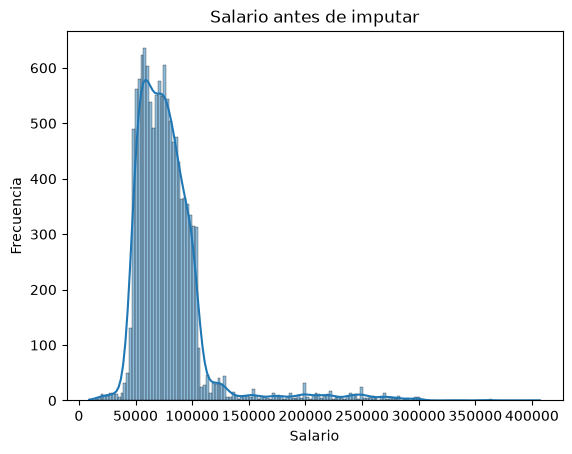

In [ ]:
sns.histplot(df_cliente["Salary"], kde=True)

plt.title("Salario antes de imputar")
plt.xlabel("Salario")
plt.ylabel("Frecuencia")
plt.show()
#Antes de imputar los nulos de Salary, vemos la distribución

In [ ]:
from sklearn.impute import KNNImputer

cols_numericas = ["Salary","CLV","Enrollment Year","Enrollment Month"]
knn_imputer = KNNImputer(n_neighbors=5)
df_cliente[cols_numericas] = knn_imputer.fit_transform(df_cliente[cols_numericas])
df_cliente["Salary"].isnull().sum()

# Imputamos el salario usando el metodo de K-Nearest Neighbors (K vecinos más cercanos).
# Buscar registros parecidos al que tiene un valor nulo y usar esos registros para estimar el valor faltante.


np.int64(0)

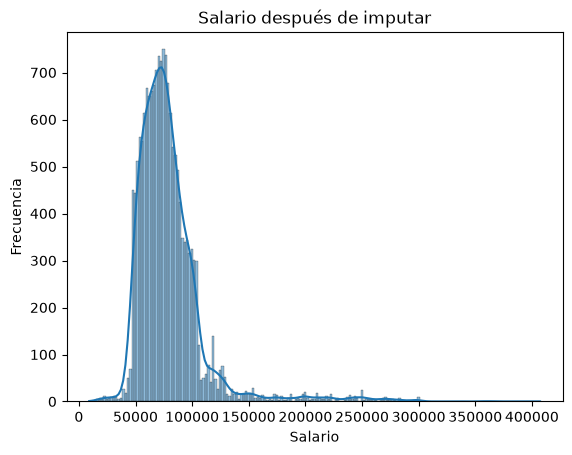

In [105]:
sns.histplot(df_cliente["Salary"], kde=True)

plt.title("Salario después de imputar")
plt.xlabel("Salario")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
duplicados = df_vuelos[df_vuelos.duplicated()]
duplicados.head(5)
# Creo una variable llamada duplicados y guardamos ahí únicamente las filas repetidas del DF vuelos

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
42,101902,2017,1,0,0,0,0,0.0,0,0
227,112142,2017,1,0,0,0,0,0.0,0,0
478,126100,2017,1,0,0,0,0,0.0,0,0
567,130331,2017,1,0,0,0,0,0.0,0,0
660,135421,2017,1,0,0,0,0,0.0,0,0


In [ ]:
duplicados = df_vuelos[df_vuelos.duplicated(keep=False)]
duplicados.sort_values(by=["Loyalty Number", "Year", "Month"]).head(5)
# Detectamos todas las columnas de cada fila y devuelve un booleno, en el que
# el parametro keep = false  significa "marca todas las que sean duplicadas", false si la fila es unica 

#.sort_values(by=[...]) ordena las filas del DataFrame duplicados según esas tres columnas

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
41,101902,2017,1,0,0,0,0,0.0,0,0
42,101902,2017,1,0,0,0,0,0.0,0,0
16942,101902,2017,2,0,0,0,0,0.0,0,0
16943,101902,2017,2,0,0,0,0,0.0,0,0
33843,101902,2017,3,0,0,0,0,0.0,0,0


In [ ]:
df_vuelos.drop_duplicates(inplace=True)
# Borramos los duplicados de vuelos porque estamos viendo pares exactamente iguales
# Mismo: cliente, año, mes, vuelos reservados, vuelos acompañados, distancia, puntos
# No hay ninguna diferencia. Eso significa: La misma observación fue registrada dos veces.

In [ ]:
df_vuelos.duplicated().sum()
# volvemos a comprobar si se han borrado los duplicados

np.int64(0)

In [ ]:
df_cliente = df_cliente.drop(columns="Cancellation Year")
df_cliente = df_cliente.drop(columns="Cancellation Month")

# Gestion de Cancellation Year y Cancellation Month
# Ambas columnas presentan aproximadamente un 87% de valores nulos.
# Estos nulos no representan un error o dato faltante, sino ausencia de cancelación registrada, lo que indica clientes activos.
# Debido a que estas variables no aportan valor a las preguntas del análisis, se eliminan del dataset.

In [112]:
df_cliente.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016.0,2.0
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,79194.0,Divorced,Star,3839.61,Standard,2016.0,3.0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,155441.0,Single,Star,3839.75,Standard,2014.0,7.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,84371.0,Single,Star,3839.75,Standard,2013.0,2.0
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014.0,10.0


### Antes de pasar a la union de datos, revisamos los posibles outliers

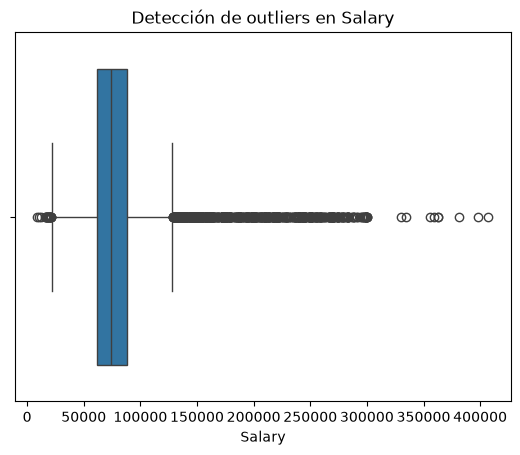

In [ ]:
sns.boxplot(x=df_cliente["Salary"])

plt.title("Detección de outliers en Salary")
plt.show()

# No se detectaron concentraciones artificiales de valores
# lo que indica que cuando se realizo la imputación generó estimaciones consistentes
# con la estructura original de los datos.
# Los valores mínimos comienzan en aproximadamente 9000, por lo que existen salarios anormalmente bajos.
# En el extremo superior únicamente se identificó un cliente con un salario superior a 400000

### - Union de datos con Merge

In [122]:
# Hacemos la union de datos con un merge y un right, el DF right es es de vuelos
# que es el que tiene mas datos, concretamente vuelos tiene 405624 entries frente a los 16737 entries de clientes
# creamos un nuevo DF llamada aerolinea
df_aerolinea = df_vuelos.merge(df_cliente, on =["Loyalty Number"], how = "right")
df_aerolinea.sample(5)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,...,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month
355611,569880,2018,9,3,3,6,3144,314.0,0,0,...,V1E 4R6,Male,Bachelor,67044.0,Married,Star,7706.04,Standard,2012.0,9.0
339737,767864,2017,11,0,0,0,0,0.0,0,0,...,J8Y 3Z5,Female,Bachelor,51573.0,Single,Star,6005.21,Standard,2018.0,5.0
263943,489985,2018,11,3,0,3,2157,215.0,0,0,...,V10 6T5,Male,Bachelor,55317.0,Divorced,Star,2531.74,Standard,2018.0,1.0
394913,802478,2017,8,0,0,0,0,0.0,0,0,...,V10 6T5,Male,College,60591.0,Single,Star,19964.40,Standard,2014.0,4.0
135214,453136,2017,9,3,3,6,2610,261.0,0,0,...,M2M 7K8,Male,Bachelor,98320.0,Married,Nova,4037.50,Standard,2015.0,11.0


In [123]:
# comprobamos que los datos se han unido bien y dan la cantidad correspondiente
df_aerolinea.shape

(403760, 23)

In [124]:
# gestion de duplicados de df_vuelos, anteriormente nos habian dado (1864), al haberlo limpiado, ahora los duplicados son cero
df_aerolinea.duplicated().sum()

np.int64(0)

In [ ]:
# Revisamos la gestion de nulos del merge
df_aerolinea.isnull().sum()/len(df_aerolinea) * 100

Loyalty Number                 0.0
Year                           0.0
Month                          0.0
Flights Booked                 0.0
Flights with Companions        0.0
Total Flights                  0.0
Distance                       0.0
Points Accumulated             0.0
Points Redeemed                0.0
Dollar Cost Points Redeemed    0.0
Country                        0.0
Province                       0.0
City                           0.0
Postal Code                    0.0
Gender                         0.0
Education                      0.0
Salary                         0.0
Marital Status                 0.0
Loyalty Card                   0.0
CLV                            0.0
Enrollment Type                0.0
Enrollment Year                0.0
Enrollment Month               0.0
dtype: float64

In [130]:
df_aerolinea.to_csv("df_final.csv")